In [1]:
import matplotlib
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.animation as animation
from IPython.display import Video
import math
import numpy as np
import sys
import os

module_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import functions
import plot_config as pc

pc.apply_custom_mpl_settings()

<h1><span style="color:orange">Numerical Simulation Laboratory (NSL)</span></h1>

<h2><span style="color:green">Numerical Exercise 10</span></h2>

This notebook aims to analyze and quantify the **computational benefits** derived from the parallelization of code applied to **stochastic optimization problems**. The analysis focuses on evaluating improvements in both **temporal performance** and the **intrinsic quality of the solution**.

The specific object of this study is the **Traveling Salesman Problem (TSP)**, a widely studied combinatorial optimization challenge classified as NP-hard. The particular instance addressed requires **finding the minimum-distance path** connecting $110$ Italian provincial capitals. A valid solution must adhere to the canonical TSP constraints: 
1. The traveller must visit **each city exactly once**.
2. The path must be **closed**.

The combinatorial nature of the search space for $N=110$ cities is factorial (up to $10^{178}$ possible path), rendering exhaustive search unfeasible. This necessitates the use of metaheuristic algorithms, such as **Genetic Algorithms (GAs)**, to find high-quality, near-optimal solutions within a reasonable timeframe.

The current implementation leverages a pre-existing Genetic Algorithm framework and extends it to a distributed computing environment.

The core experimental objective is the implementation of specialized routines for the **exchange** of superior solutions (i.e., **migration**) among distinct parallel processes during the generation lifecycle. This parallelization strategy employs the **Island Model** (or Migratory GA).

In this architecture, the total population is partitioned into $p$ semi-independent subpopulations, each managed by an individual process running its own GA instance. The periodic migration of elite individuals achieves a dual computational advantage:

- **Enhanced Exploration and Robustness**: The semi-independence of the islands promotes **genetic diversification** across the population landscape. This significantly mitigates the risk of **premature convergence** to local optima, ensuring a more thorough **exploration** of the vast solution space and consequently increasing the probability of locating the global optimum.

- **Performance Acceleration**: Utilizing distributed computational resources achieves a substantial **reduction in the overall execution time**, providing an effective **speed-up** for the optimization process.

<h2><span style="color:darkviolet">Parallel Programming</span></h2>

The concept of **parallel programming** is central to modern scientific research, particularly in the realm of numerical simulations and complex computational problems. The computational power required for many large-scale tasks often exceeds the capabilities of standard, serially-executing processors. This necessity is further compounded by the physical constraints outlined by **Moore's Law**.
The empirical observation that the number of transistors on a microchip doubles approximately every two years is currently facing significant limitations. In contemporary chip technology, transistor gate sizes are approaching the atomic scale (in the order of $2–3 \text{ nm}$). Scaling down further introduces dominant **quantum phenomena**, which render classical computing models unreliable and mark the boundary towards Quantum Computing.

<div style="text-align: center;">
<img src="images/moores_law.jpg" alt="Moore's Law" width="600">
</div>

Consequently, the most viable path to achieve further increases in computational performance is through **parallelization**. This paradigm involves decomposing a large task (requiring $N$ operations) into smaller sub-tasks, which are then distributed among multiple computing agents (processors or cores) to achieve a solution in significantly less time.

#### Fundamental Performance Metrics

In parallel computing, the effectiveness of an implementation is measured using three fundamental metrics:

1. **Cost** ($C_p$): Defined as the product of the number of processors ($p$) and the parallel execution time ($t_p$): $$C_p = p \cdot t_p.$$ It represents the total CPU time consumed by all processing units collectively.

2. 

2. **Speed-up** ($S_p$): The ratio of the serial execution time ($t_1$) to the parallel execution time ($t_p$): $$S_p = \frac{t_1}{t_p}.$$ Speed-up quantifies the acceleration gained by using multiple processors. Its behavior is characterized by different regimes, such as:
    - Linear (Ideal): $S_p = p$, suggesting perfect scalability where execution time halves when the processor count doubles.
    - Sub-linear (Actual): The curve flattens due to factors such as communication overhead and the presence of non-parallelizable code segments.

3. **Efficiency** ($E_c$) : Measures the utilization of the available computational resources, defined as the ratio of the speed-up to the number of processors: $$E_p = \frac{S_p}{p} = \frac{t_1}{C_p}.$$ Efficiency provides a measure of how effectively all cores are being utilized. Ideally, $E_p = 1.0$ (or 100%). In real-world scenarios, $E_p$ typically decreases as $p$ increases, due to synchronization delays and inter-process communication overhead.

The primary goal of parallel optimization is to maximize the combined benefit of speed-up and efficiency. An optimal configuration is one that achieves a satisfactory reduction in execution time while maintaining high resource utilization.

<div style="text-align: center;">
<img src="images/efficiency_speedup_cost.jpg" alt="Efficiency, Speed-up behaviours as incrementing processes" width="400">
</div>

Early thinking on parallelization was dominated by **Amdahl's Law** (circa 1960s), which posits that the maximum achievable speed-up is fundamentally limited by the inherently serial fraction of the algorithm. Assuming $f$ is the fraction of the code that can be parallelized, the total execution time $t_p$ on $p$ processors is given by:

$$t_p = \frac{f \cdot t_1}{p} + (1-f) \cdot t_1,$$

where $(1-f)$ is the serial fraction. According to Amdahl, the maximum speed-up, even with $p \to \infty$, is bounded by $S_{\max} = \frac{1}{1-f}$. This seemingly restrictive view suggested that parallelization was severely limited. However, **Gustafson's Law** challenged this perspective by introducing the concept of **scaled speed-up**. Gustafson argued that as computational complexity (problem size) increases, the serial fraction ($1-f$) often tends to diminish relative to the overall workload. This concept validates the use of parallel computing for tackling problems of greater magnitude, as demonstrated by the ability of parallel systems to solve larger, more complex scientific problems.

#### High-Performance Computing (HPC) Architectures

A **Parallel Computer** is a collection of processing elements designed to communicate and cooperate to rapidly solve computationally intensive tasks. HPC architectures are most intuitively classified based on memory management:

<div style="text-align: center;">
<img src="images/memory_classification.jpg" alt="HCP memory classification" width="600">
</div>

- **Shared Memory (Symmetric Multiprocessor - SMP)**: All processors share a single, unified address space. Any process can access any memory location, simplifying data exchange but introducing challenges in managing concurrent access.

- **Non-Uniform Memory Access (NUMA)**: Memory is physically distributed among processors, but still logically accessible to all. Access time varies depending on the memory's physical location relative to the processor.

- **Distributed Memory (Massively Parallel Processor - MPP)**: Each processor possesses its own private memory space and local I/O management. Data exchange between processes is exclusively managed through explicit **message passing** over an interconnection network. This architecture, implemented using libraries like MPI, allows for the highest degree of scalability and is the foundation for the current study.

<div style="text-align: center;">
<img src="images/mpp.jpg" alt="Massively Parallel Processor" width="600">
</div>

#### The SPMD Paradigm

The computational work presented here is structured using the **Single Program Multiple Data (SPMD)** paradigm. In the SPMD model, a single executable program is launched and executed simultaneously by all processes ($p$). Each process operates independently, executing the same code path, and relies on explicit **message passing routines** to exchange data and synchronize only when required by the application logic.

<div style="text-align: center;">
<img src="images/spmd.jpg" alt="Single Program Multiple Data" width="600">
</div>


<h2><span style="color:darkviolet">The Message Passing Interface (MPI) and Communication Primitives</span></h2>

Communication among the distinct processes in this study is managed using the **OpenMPI** library, a prominent implementation of the **Message Passing Interface (MPI)** standard. MPI defines an Application Programming Interface (API) for inter-process communication, which is intrinsically tied to the **Distributed Memory Architecture** model.

#### MPI Program Lifecycle and Communicators

An MPI program adheres to a rigorous lifecycle managed by specific initialization and finalization routines:

- **Initialization**: The function `MPI_Init(int *argc, char ***argv)` must be the first MPI call. It starts the communication environment, handles command-line input, and prepares the system for parallel operations.

- **Finalization**: Upon completion of all parallel operations, the environment must be correctly cleaned up using `MPI_Finalize()`. No MPI functionality, including message passing, can be invoked after this call.

MPI processes are logically organized into groups defined by **Communicators**. A Communicator establishes the logical communication universe for all subsequent operations. The initial default group, that includes all processes launched, is `MPI_COMM_WORLD`. Within a Communicator, each process is uniquely identified by a **Rank (ID)**, a non-negative integer ranging from $0$ to $N-1$, where $N$ is the total number of processes (`size`) in the group. Critical functions for identification are:
- `MPI_Comm_size(comm, &size)`: Returns the total number of processes (`size`).
- `MPI_Comm_rank(comm, &rank)`: Returns the unique Rank (`rank`) of the calling process, which serves as the logical address in P2P communication.

#### Data Typing and Message Envelope

For effective communication across heterogeneous hardware architectures, exchanged data must be standardized. MPI addresses this through its **Data Types** and the **Message Envelope** concept.

It is mandatory to use predefined MPI Data Types (e.g., `MPI_INT`, `MPI_DOUBLE`, `MPI_CHAR`) to describe the structure of data within the user buffer. This standard mapping ensures the correct interpretation and translation of data between systems.

<div style="text-align: center;">
<img src="images/MPI_data_types.jpg" alt="MPI Data Types" width="600">
</div>

Beyond the data itself (buffer address, count, type), every MPI message includes an envelope that provides critical matching information:

- **Source/Destination**: The Rank of the intended receiver (specified by the sender) and the Rank of the actual sender (expected by the receiver).

- **Tag**: An arbitrary integer used to distinguish different communication flows and allows the receiver to selectively target a message.

- **Communicator**: Ensures that communication occurs only between processes within the same logical group.

#### Point-to-Point (P2P) Communications

P2P communications form the backbone of MPI, enabling the direct exchange of data between two processes. This process involves **copying** data **from** the **sender's user buffer** into a **system buffer**, **transmitting** it across the **network**, and then **copying** it **from** the **system buffer** into the **receiver's user buffer**.

<div style="text-align: center;">
<img src="images/p2p.jpg" alt="Point to Point communication" width="600">
</div>

P2P primitives are categorized based on their completion behavior:

- **Blocking Primitives** (`MPI_Send`, `MPI_Recv`) : These are the simplest and most reliable primitives, guaranteeing data integrity but potentially inducing **latency** and **deadlock**. Execution is blocked until the data transfer to/from the *system buffer* is completed. *In bidirectional exchanges, particularly with large buffers, care must be taken to avoid deadlock—a situation where both processes are simultaneously blocked waiting for the other to start the receiving operation. A common strategy to prevent this is by explicitly staggering the order of calls (one process calls Send then Recv, the other calls Recv then Send).*

- **Non-Blocking Primitives** (`MPI_Isend`, `MPI_Irecv`) : These calls initiate the data transfer and **return immediately**, allowing the process to continue with independent computational tasks while the transfer proceeds asynchronously in the background. This ability to overlap communication with computation is highly valuable for **latency hiding**. Since non-blocking primitives return immediately, they do not guarantee the local buffer's immediate safety (for `Isend`) or the data's availability (for `Irecv`). Explicit synchronization is required via the `MPI_Wait()` primitive, which blocks execution until the operation associated with the specific `MPI_Request` object is locally complete.

In parallel applications using schemes such as the **Ring Topology** (as used in the Island Model for path exchange), two processes often need to exchange messages simultaneously with their neighbors. The `MPI_Sendrecv` primitive is specifically designed to safely and efficiently resolve potential deadlocks by atomically executing a send and a receive operation in a single call. **Crucially, the sender's and receiver's buffers used in this primitive must occupy distinct and non-overlapping memory locations.**
This routine is the primary mechanism used for the exchange of elite chromosomes in the Island Model, allowing a process to send its best solutions to one neighbor while simultaneously receiving immigrants from another.

A special variant, `MPI_Sendrecv_replace`, is available for cases where the data to be sent and received must occupy the same buffer, replacing the outgoing content with the incoming data upon completion. `MPI_Sendrecv_replace` is particularly advantageous from a memory architecture standpoint, as it obviates the need for dynamic allocation of a separate receive buffer, thereby contributing to **execution efficiency** and **reducing** the program’s **overall memory usage**.

#### Collective Communications

Beyond P2P, MPI provides a set of **Collective Operations** that involve a defined group of processes within a Communicator. These operations are crucial for managing data movement, synchronization, and result aggregation in an optimized manner. A key requirement is that these operations must be invoked by *all* members of the Communicator, with agreement on parameters (Root process, data types, counts, operation type, etc.).

Key collective operations include:

- **Broadcast** (`MPI_Bcast`): The designated Root process sends the identical message to all other processes in the group.

- **Scatter** (`MPI_Scatter`): The Root distributes contiguous blocks from a send array, providing a unique block to each process.

- **Gather** (`MPI_Gather`): The inverse of Scatter. All processes send their local data to the Root, which concatenates them in Rank order.

- **Reduce** (`MPI_Reduce`): Performs a global reduction operation (e.g., MPI_SUM, MPI_MAX, user-defined operations) on data contributed by all processes, storing the single result only at the Root.

- **Allreduce** (`MPI_Allreduce`): Performs the same global reduction but distributes the final result to all processes in the Communicator.

<div style="text-align: center;">
<img src="images/collective_calls.jpg" alt="Collective Calls" width="600">
</div>

<h2><span style="color:darkviolet">Implementation</span></h2>

The parallelization of the GA for the TSP is implemented using the **Island Model** paradigm over a Distributed Memory Architecture (MPI). The core of this implementation lies in the design of the communication routine, which balances the evolutionary autonomy of each local population with the need for global information exchange.

The communication mechanism for the periodic exchange of elite solutions (migration) is a **Ring Topology with Periodic Boundary Conditions** (PBCs). This ensures that every process communicates exclusively with its two immediate neighbors.

The **migration rate** is set at $5\%$ of the local population. Given a population size of $2000$ individuals per process, this translates to the exchange of $100$ elite chromosomes. The exchange direction is defined such that each Rank `rank` sends its best individuals to Rank `(rank+1) % size` and simultaneously receives immigrants from Rank `(rank-1+size) % size`. This ensure PBCs architecture.

The **migration frequency** is set to once every $100$ generations. This low frequency is a strategic choice, granting each process sufficient autonomy to thoroughly explore its local fitness landscape before external solutions are injected. This intentional separation maintains the genetic diversity characteristic of the Island Model.

Since MPI does not support the direct transfer of complex C++ objects (like the `Chromosome` class, which contains dynamic data structures such as the Armadillo vector), the data must be `serialized`.

1. **Serialization**: The path information (the sequence of city indices) for the `_nexchange` elite chromosomes is extracted and packed into a contiguous dynamic integer array, `_exchange_buffer`. The size of this buffer is `_buffer_size = _nexchange * _ncity` and is set during the initialization routine.

2. **Transmission**: The `MPI_Sendrecv_replace` primitive is used to atomically exchange this buffer.

3. **Replacement Strategy**: The incoming $100$ immigrant paths replace the `_nexchange` worst individuals in the local population. This approach strategically introduces superior solutions into the population while discarding the weakest ones, immediately improving the average quality. This also ensures that the local best solutions (the `_nelite` individuals) are preserved before migration occurs.

4. **Post-Migration Processing**: Upon reception, the new paths are unpacked from the buffer, inserted into the population, their integrity is validated (`check_path_properties`), and their fitness value (`compute_loss`) is recalculated by accessing the distance matrix. The population is then immediately re-sorted to integrate the new individuals and maintain the elitism structure for the subsequent generation.

This routine is performed by the following code section:

```cpp
    void Population::process_path_exchange(int size, int rank){

        for(int i = 0; i < _nexchange; i++){   
            for(int j = 0; j < _ncity; j++){
                _exchange_buffer[j + _ncity*i] = _population(i).get_city(j);
            }
        }

        MPI_Status status;
        const int sendtag = 101; 
        const int recvtag = 101;
        
        int send_to = (rank + 1) % size;
        int recv_from = (rank - 1 + size) % size;

        MPI_Sendrecv_replace(_exchange_buffer, _buffer_size, MPI_INT, send_to, sendtag, recv_from, recvtag, MPI_COMM_WORLD, &status);

        int start_idx = _npath - _nexchange;

        for(int i = 0; i < _nexchange; i++){
            for(int j = 0; j < _ncity; j++){
                _population(start_idx + i).set_city(j, _exchange_buffer[j + _ncity*i]);
            }
            _population(start_idx + i).check_path_properties();
            _population(start_idx + i).compute_loss(_distance);

        sort();

        return;
    }
```

<h2><span style="color:darkviolet">Serial and Parallel runs</span></h2>

The experimental methodology is centered on comparing the performance metrics obtained from the distributed parallel execution against the sequential baseline. To ensure a methodologically **honest comparison of total computational work**, the total effective population size was maintained identically at $20000$ **individuals** across both scenarios.

In the **Sequential Run**, the entire population evolves within a single process, subject to a conventional elitism rate. In the **Parallel Run (Island Model)**, the total population is distributed across $10$ independent processes, where each process manages a local population of $2000$ individuals and its own elite class.

Both simulations were run for a fixed number of $1000$ **generations**, ensuring that the comparison of wall-clock time is based on the same total number of evolutionary steps. Furthermore, the probabilities for all genetic operators (crossover and mutations) were kept constant to isolate the impact of parallelization and migration.

The input parameters used for both simulations are summarized in the following Table:

<div align="center">



| Parameter | Parallel run (p = 10) | Serial run (p = 1) |
| :--- | :--- | :--- |
| RND_ROW (RNG Seed Offset) | 0 | 0 |
| N_PATH (Local Population Size) | 2000 | 20000 |
| N_ELITE (Elite Size) | 200 (10%) | 2000 (10%) |
| N_CITY (Number of Cities) | 110 | 110 |
| CITY_DISTRIBUTION | ITALY | ITALY |
| N_GENERATIONS | 1000 | 1000 |
| P_SWAP (Swap Mutation Probability) | 0.10 | 0.10 |
| P_SHIFT (Shift Mutation Probability) | 0.10 | 0.10 |
| P_CROSSOVER (Crossover Probability) | 0.80 | 0.80 |
| P_INVERSION (Inversion Mutation Probability) | 0.10 | 0.10 |
| N_CHROMO_EXCHANGED (Migration Size) | 100 (5%) | N/A |
| N_MESSAGE (Migration Frequency Denominator) | 10 | N/A |

</div>

The simulations were executed using the mpirun command to initiate the MPI environment.

The **Sequential Run** was launched using a single process:

<div align="center">

```bash
    mpirun -np 1 ./GA.exe
```

</div>

The **Parallel Run** utilized 10 processes, establishing the distributed memory architecture and the Ring Topology:

<div align="center">

```bash
    mpirun -np 10 ./GA.exe
```

</div>

|  Process   |       Min best loss       |          Min best half pop avg loss           |
------------------------------------------------------------------------------------------
|     0      |         53.77800          |                   53.92800                    |


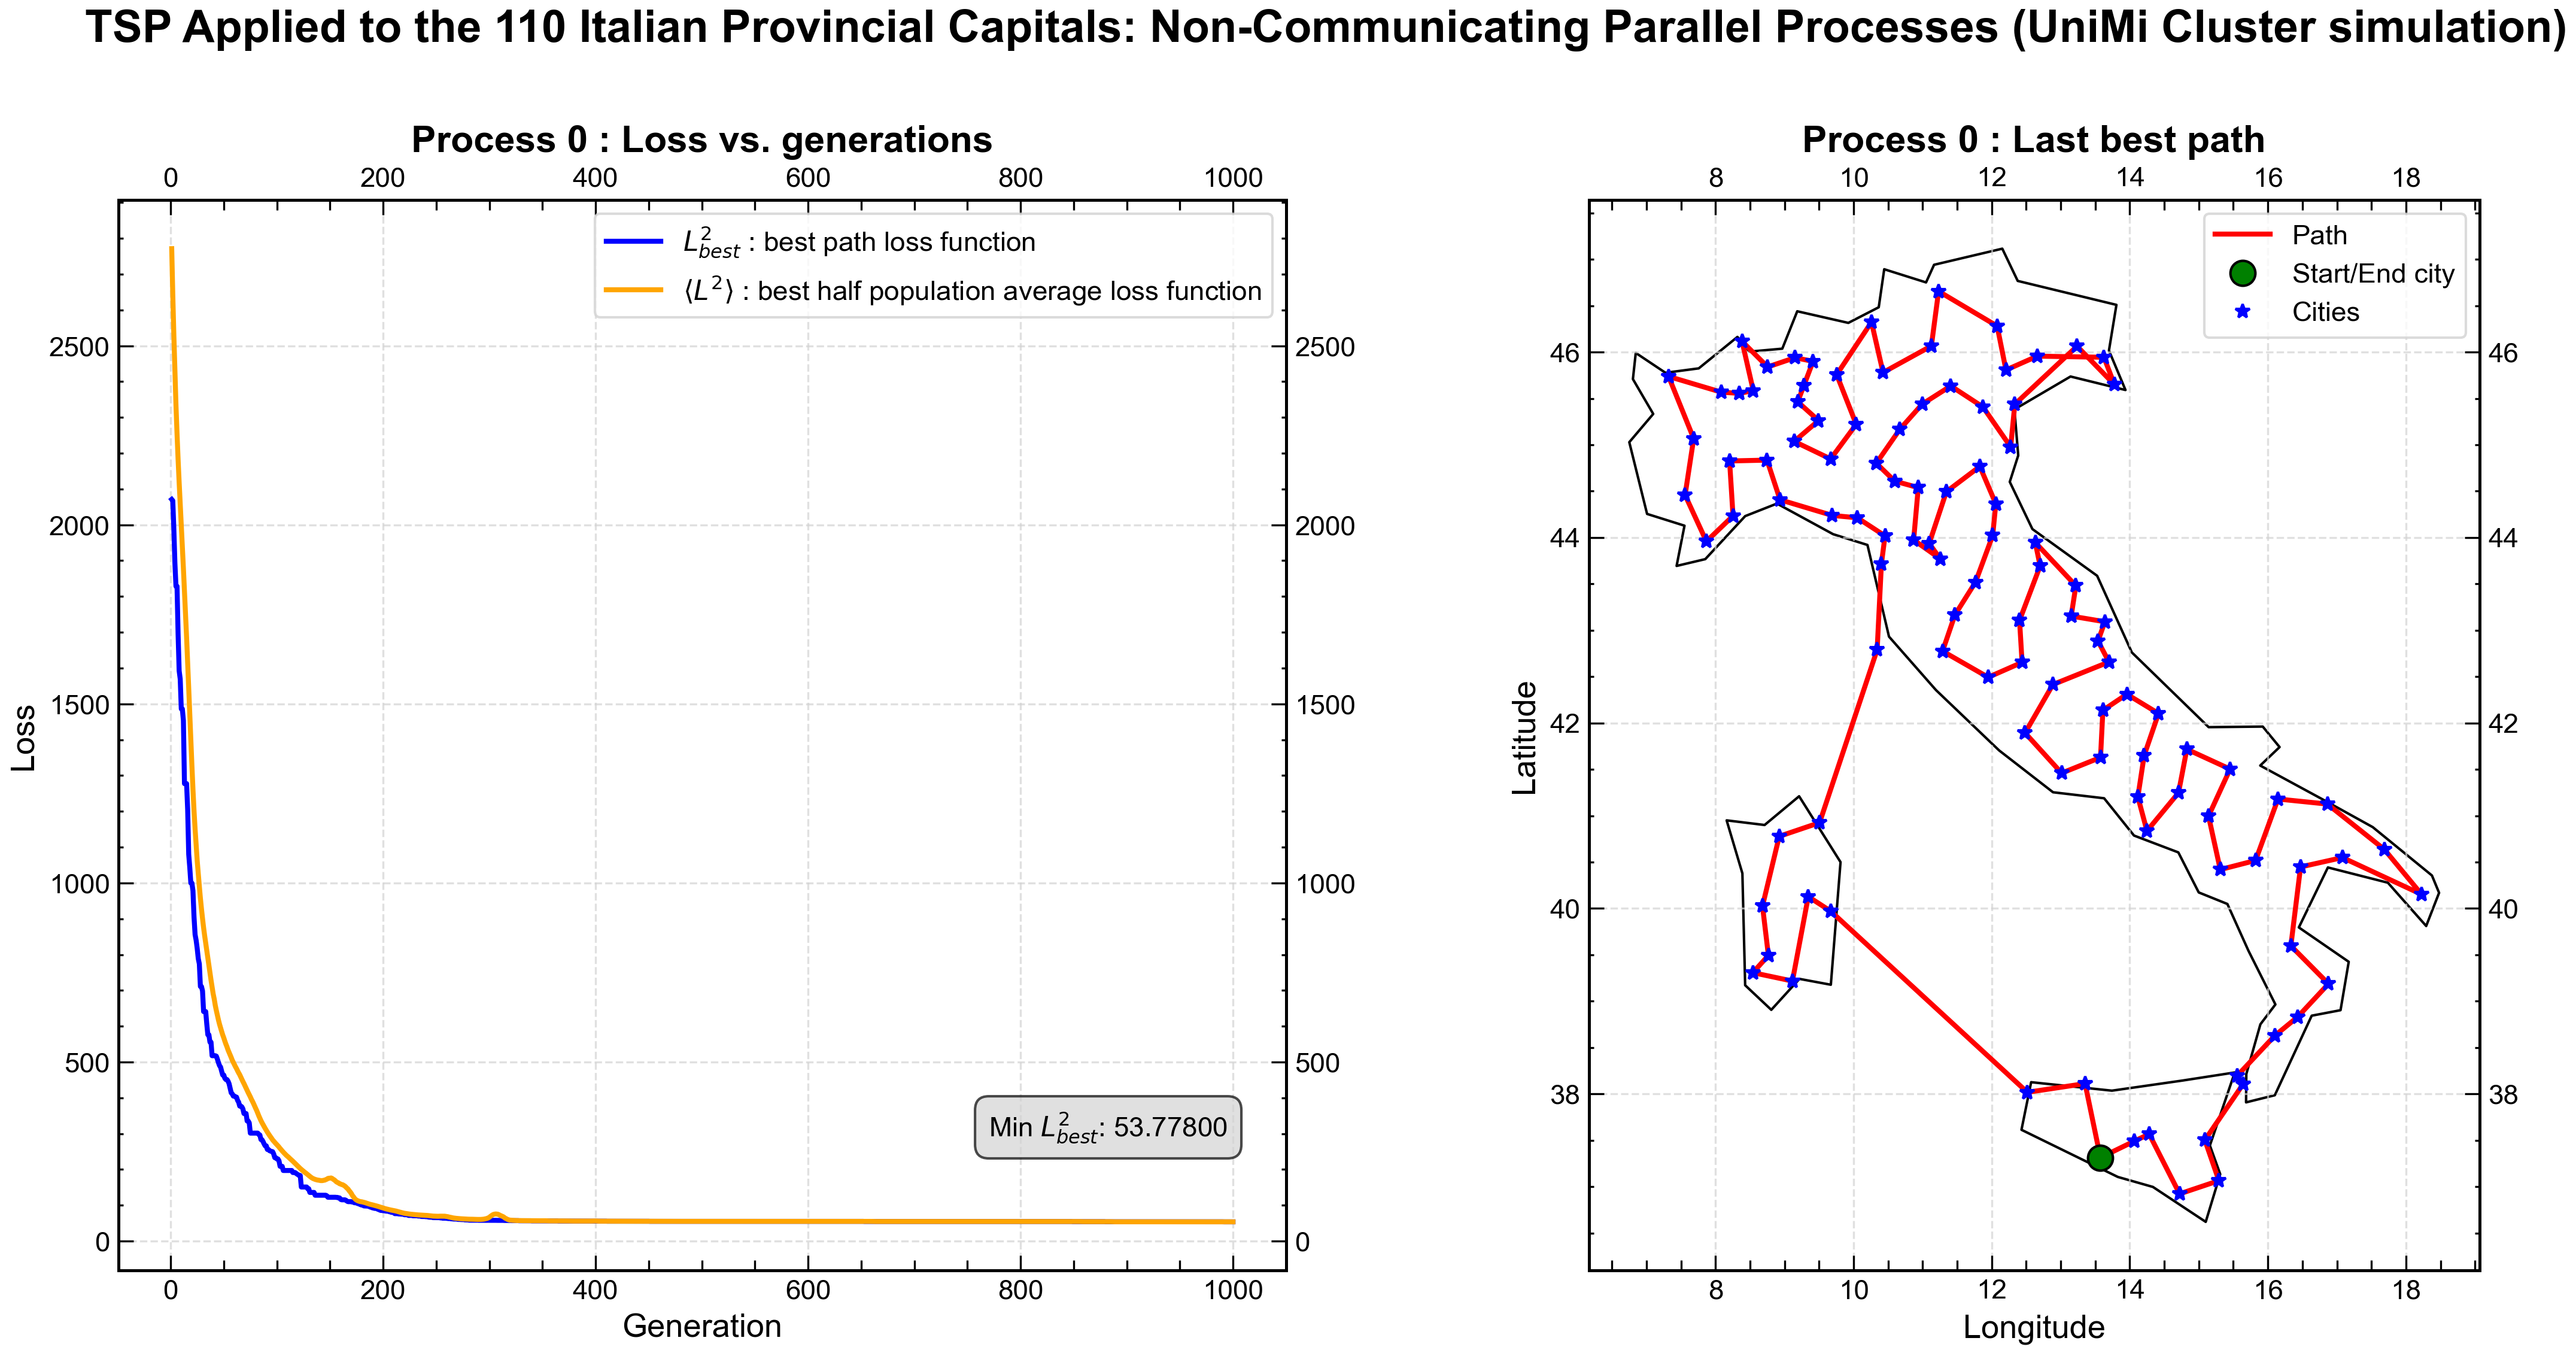

In [2]:
n_process = 1
n_individuals = 20000

fig, axs = plt.subplots(1,2,figsize=(15,8))

fig.suptitle("TSP Applied to the 110 Italian Provincial Capitals: Non-Communicating Parallel Processes (UniMi Cluster simulation)", fontweight='bold', fontsize=18)

w_proc = 10
w_best = 25
w_mean = 45

print('=' * (w_proc + w_best + w_mean + 10))
header = f"| {'Process':^{w_proc}} | {'Min best loss':^{w_best}} | {'Min best half pop avg loss':^{w_mean}} |"
print(header)
print('-' * (w_proc + w_best + w_mean + 10))

shapefile_path = 'natural_earth_data/ne_110m_admin_0_countries.shp'
world = gpd.read_file(shapefile_path)
italy = world[world['NAME'] == 'Italy']


generations, best_loss = np.loadtxt('NO_MIGRATION/OUTPUT/BEST_LOSS/best_loss_0.dat', usecols=(0,1), unpack=True)
mean_loss = np.loadtxt('NO_MIGRATION/OUTPUT/HALF_POP_MEAN_LOSS/half_pop_mean_loss_0.dat', usecols=(1))
city_label, x,y = np.loadtxt('NO_MIGRATION/OUTPUT/BEST_CITY_DISTRIBUTION/best_city_distribution0.dat', usecols=(0,1,2), unpack=True)

val_best = np.min(best_loss)
val_mean = np.min(mean_loss)
text = f'Min $L^2_{{best}}$: {val_best:.5f}'

axs[0].set_title("Process 0 : Loss vs. generations")
axs[0].plot(generations, best_loss, color='blue', label=r'$L^2_{best}$ : best path loss function')
axs[0].plot(generations, mean_loss, color='orange', label=r'$\langle L^2 \rangle$ : best half population average loss function')
axs[0].text(0.95, 0.15, text, transform=axs[0].transAxes, verticalalignment='top', horizontalalignment='right', bbox={'boxstyle': 'round,pad=0.5','facecolor': 'lightgrey','alpha': 0.7,'edgecolor': 'black'})
axs[0].set_xlabel('Generation')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].set_title("Process 0 : Last best path")
italy.plot(ax=axs[1], color='white', edgecolor='black')
axs[1].plot(x, y, color='red', label='Path')
axs[1].plot(x[0], y[0], color='green', linestyle='none', marker='o', markersize=10, markeredgecolor='black', label='Start/End city')
axs[1].plot(x[1:-1], y[1:-1], color='blue', linestyle='none', marker='*', markersize=6, label='Cities')
axs[1].set_xlabel('Longitude')
axs[1].set_ylabel('Latitude')
axs[1].legend()

print(f"| {'0':^{w_proc}} | {val_best:^{w_best}.5f} | {val_mean:^{w_mean}.5f} |")

print('=' * (w_proc + w_best + w_mean + 10))

fig.tight_layout(rect=[0, 0.03, 1, 0.97])
fig.savefig("NO_MIGRATION/plot/loss_&_best_path.png")
plt.show()

In [3]:
n_process = 10
n_individuals = 2000

fig, axs = plt.subplots(n_process,2,figsize=(15,8*n_process))

fig.suptitle("TSP Applied to the 110 Italian Provincial Capitals: Communicating Parallel Processes (UniMi Cluster simulation)", fontweight='bold', fontsize=18)

w_proc = 10
w_best = 25
w_mean = 45

print('=' * (w_proc + w_best + w_mean + 10))
header = f"| {'Process':^{w_proc}} | {'Min best loss':^{w_best}} | {'Min best half pop avg loss':^{w_mean}} |"
print(header)
print('-' * (w_proc + w_best + w_mean + 10))

shapefile_path = 'natural_earth_data/ne_110m_admin_0_countries.shp'
world = gpd.read_file(shapefile_path)
italy = world[world['NAME'] == 'Italy']



for i in range(n_process):

    generations, best_loss = np.loadtxt('MIGRATION/OUTPUT/BEST_LOSS/best_loss_' + str(i) + '.dat', usecols=(0,1), unpack=True)
    mean_loss = np.loadtxt('MIGRATION/OUTPUT/HALF_POP_MEAN_LOSS/half_pop_mean_loss_' + str(i) + '.dat', usecols=(1))
    city_label, x,y = np.loadtxt('MIGRATION/OUTPUT/BEST_CITY_DISTRIBUTION/best_city_distribution' + str(i) + '.dat', usecols=(0,1,2), unpack=True)

    val_best = np.min(best_loss)
    val_mean = np.min(mean_loss)
    text = f'Min $L^2_{{best}}$: {val_best:.5f}'

    axs[i][0].set_title("Process " + str(i) + " : Loss vs. generations")
    axs[i][0].plot(generations, best_loss, color='blue', label=r'$L^2_{best}$ : best path loss function')
    axs[i][0].plot(generations, mean_loss, color='orange', label=r'$\langle L^2 \rangle$ : best half population average loss function')
    axs[i][0].text(0.95, 0.15, text, transform=axs[i][0].transAxes, verticalalignment='top', horizontalalignment='right', bbox={'boxstyle': 'round,pad=0.5','facecolor': 'lightgrey','alpha': 0.7,'edgecolor': 'black'})
    axs[i][0].set_xlabel('Generation')
    axs[i][0].set_ylabel('Loss')
    axs[i][0].legend()

    axs[i][1].set_title("Process " + str(i) + " : Last best path")
    italy.plot(ax=axs[i][1], color='white', edgecolor='black')
    axs[i][1].plot(x, y, color='red', label='Path')
    axs[i][1].plot(x[0], y[0], color='green', linestyle='none', marker='o', markersize=10, markeredgecolor='black', label='Start/End city')
    axs[i][1].plot(x[1:-1], y[1:-1], color='blue', linestyle='none', marker='*', markersize=6, label='Cities')
    axs[i][1].set_xlabel('Longitude')
    axs[i][1].set_ylabel('Latitude')
    axs[i][1].legend()

    print(f"| {i:^{w_proc}} | {val_best:^{w_best}.5f} | {val_mean:^{w_mean}.5f} |")

print('=' * (w_proc + w_best + w_mean + 10))

fig.tight_layout(rect=[0, 0.03, 1, 0.98])
fig.savefig("MIGRATION/plot/loss_&_best_path.png")
plt.show()

|  Process   |       Min best loss       |          Min best half pop avg loss           |
------------------------------------------------------------------------------------------
|     0      |         54.55700          |                   54.55700                    |
|     1      |         54.39100          |                   54.39100                    |
|     2      |         53.57380          |                   53.57380                    |
|     3      |         53.52630          |                   53.52630                    |
|     4      |         53.52630          |                   53.52630                    |
|     5      |         54.28680          |                   54.28680                    |
|     6      |         54.28680          |                   54.28680                    |
|     7      |         54.28680          |                   54.28680                    |
|     8      |         55.10640          |                   55.10640                    |

In [4]:
time_serial = np.loadtxt('NO_MIGRATION/OUTPUT/exe_time.dat', usecols=(1))
time_parall = np.loadtxt('MIGRATION/OUTPUT/exe_time.dat', usecols=(1))
best_loss_serial = np.loadtxt('NO_MIGRATION/OUTPUT/BEST_LOSS/best_loss_0.dat', usecols=(1), skiprows=1000)
best_loss_parall = np.loadtxt('MIGRATION/OUTPUT/BEST_LOSS/best_loss_3.dat', usecols=(1), skiprows=1000)

print('Population size = 20000')
print('===========================================')
print('| SIMULATION | EXECUTION_TIME | BEST_LOSS |')
print('-------------------------------------------')
print(f'|   SERIAL   | {time_serial:14.4f} | {best_loss_serial:9.5f} |')
print(f'|  PARALLEL  | {time_parall:14.4f} | {best_loss_parall:9.5f} |')
print('===========================================')
print(f'Speed-Up : {time_serial/time_parall:.2f}')
print(f'Loss Improvement : {np.abs(best_loss_serial-best_loss_parall)*100/best_loss_serial:.2f}%')

time_serial = np.loadtxt('NO_MIGRATION_2000/OUTPUT/exe_time.dat', usecols=(1))
time_parall = np.loadtxt('MIGRATION_200/OUTPUT/exe_time.dat', usecols=(1))
best_loss_serial = np.loadtxt('NO_MIGRATION_2000/OUTPUT/BEST_LOSS/best_loss_0.dat', usecols=(1), skiprows=1000)
best_loss_parall = np.loadtxt('MIGRATION_200/OUTPUT/BEST_LOSS/best_loss_1.dat', usecols=(1), skiprows=1000)


print('\nPopulation size = 2000')
print('===========================================')
print('| SIMULATION | EXECUTION_TIME | BEST_LOSS |')
print('-------------------------------------------')
print(f'|   SERIAL   | {time_serial:14.4f} | {best_loss_serial:9.5f} |')
print(f'|  PARALLEL  | {time_parall:14.4f} | {best_loss_parall:9.5f} |')
print('===========================================')
print(f'Speed-Up : {time_serial/time_parall:.2f}')
print(f'Loss improvement : {np.abs(best_loss_serial-best_loss_parall)*100/best_loss_serial:.2f}%')

Population size = 20000
| SIMULATION | EXECUTION_TIME | BEST_LOSS |
-------------------------------------------
|   SERIAL   |      1894.7600 |  53.77800 |
|  PARALLEL  |        59.9937 |  53.52630 |
Speed-Up : 31.58
Loss Improvement : 0.47%

Population size = 2000
| SIMULATION | EXECUTION_TIME | BEST_LOSS |
-------------------------------------------
|   SERIAL   |        46.9610 |  64.63690 |
|  PARALLEL  |         6.4279 |  60.55440 |
Speed-Up : 7.31
Loss improvement : 6.32%


<h2><span style="color:darkviolet">Conclusions</span></h2>

The analysis of the experimental results yields three fundamental conclusions quantifying the dual benefits of parallelization:

1. The most significant finding emerges from the high-fidelity comparison ($N = 20000$). While the **solution quality remained comparable** (a marginal improvement of $0.47\%$), the **execution time was drastically reduced**, resulting in a speed-up of $S_{10} = 31.58$ on $10$ processes. This **super-linear behavior** ($S_p > p$) is a manifestation of stochastic acceleration. It highlights a profound algorithmic advantage: fragmenting the population into semi-independent "islands" allows for the simultaneous exploration of distinct basins of attraction within the search space. Migration subsequently acts as a potent catalyst, propagating optimal genetic traits across the topology. In essence, the parallel system does not merely "compute faster" but performs a more effective search, converging to a near-optimal solution in significantly fewer effective generations than the monolithic process.

2. The low-fidelity comparison ($N = 2000$) demonstrated the superiority of the parallel model in terms of robustness and quality. With a reduced total population, the serial algorithm converged prematurely to a local optimum ($L^2 \approx 64.6$). Conversely, the Island Model, operating under the exact same workload, maintained sufficient genetic diversity to locate a significantly better solution ($L^2 \approx 60.5$), yielding a $6.32\%$ improvement. This confirms that the **geographic segregation** of subpopulations is an **effective mechanism** for preserving genotypic variance, thereby mitigating the risk of premature convergence. The ability to replace the least fit individuals with high-quality immigrants is fundamental to regenerating the local population.

#### Future Improvements

In light of these results, the following directions are identified to further optimize the solver and deepen the topological analysis:

1. **Payload Optimization**: The current implementation incurs the overhead of recalculating the fitness (`compute_loss`) for immigrant chromosomes. A significant optimization would involve modifying the serialization buffer to include the chromosome's pre-calculated loss value, eliminating the need for local distance matrix access and recalculation upon reception.

2. **Advanced Exchange Topologies**: The Ring Topology, while robust, could be compared against alternative migration topologies. For instance, a centralized exchange mechanism based on `MPI_Allgather` would enable an "all-to-all" migration, where every process receives solutions from all other islands simultaneously. This approach is particularly interesting as it would significantly **increase the variability of local solutions**, since each process (island) would contribute its best individuals, pushing the model toward a more highly connected panmictic regime and potentially enhancing the exploration of the search space.

3. **Parameter Tuning**: Further study could focus on optimizing key parameters such as the **migration frequency** and the **migration rate**, as these parameters critically influence the balance between exploration (diversity) and exploitation (convergence).

In conclusion, the parallel approach is confirmed not merely as a necessity for reducing computation time, but as a **superior and more robust algorithmic strategy** for solving complex combinatorial optimization problems, providing both substantial time gains and a higher probability of reaching the global solution.